 <font size="10">**Notebook 06: scVI integration of Whole Embryo scRNA-seq data: part 4**</font>
***

<div class="alert alert-info">
    
<b> <h1> ℹ️ <strong> <font size="6" color="black"> Important notebook information </font> </strong> </h1> </b>
    <hr>
    <font size="4" color="black">
        The purpose of this notebook is to score generated scVI models and KNN graphs to determine a good starting embedding for the Whole Embryo scRNA-seq data  <br> <br>
    This notebook will take into account both donor and chemistry as these were the batch covariates corrected for as these have been show to qualatatively introduce the most technical batch  <br> <br>
    </font>

## Import packages

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import nltk

## Read in csv summaries into a dictionary

In [2]:
path = os.getcwd()

scoring_dict = {}

for d in os.listdir(path):
    if(d.endswith("scvi_outs")):
        sub_dict = {}
        sub_dict['model_scores'] = pd.read_csv(path + '/' + d + '/plot_outputs/scoring/Scoring_table_for_X_umap_neighbours_15_20220725.csv', index_col=0)
        sub_dict['h_sample_scores'] = pd.read_csv(path + '/' + d + '/plot_outputs/scoring/sil_sample_scores_for_haniffa_ID_on_X_umap_neighbours_15_20220725.csv', index_col=0)
        sub_dict['k_sample_scores'] = pd.read_csv(path + '/' + d + '/plot_outputs/scoring/sil_sample_scores_for_10x_kit_on_X_umap_neighbours_15_20220725.csv', index_col=0)
        scoring_dict[d] = sub_dict
        del sub_dict

## convert dictionary to dataframes within a dictionary

In [3]:
model_scoring_dict = {}
meta_cats = ['haniffa_ID','10x_kit']

model_scores_df = pd.DataFrame()
model_names = []
for k in scoring_dict.keys():
    model_scores_df = pd.concat([model_scores_df,scoring_dict[k]['model_scores']],ignore_index = True, sort = False).reset_index(drop=True)
    num_list=[i for i in k.split("_") if i.isnumeric()]
    model_names.append('Model_latent_' + num_list[0] + '_batch_size_' + num_list[1])
    
model_scores_df.insert(loc=0, column='Model', value = list(np.repeat(list(model_names),2)))
model_scoring_dict['overall'] = model_scores_df
model_scoring_dict[meta_cats[0]] = model_scores_df[model_scores_df.meta_cat.isin([meta_cats[0]])]
model_scoring_dict[meta_cats[1]] = model_scores_df[model_scores_df.meta_cat.isin([meta_cats[1]])]

In [4]:
model_scoring_dict['haniffa_ID']

,Model,Basis,meta_cat,Purity_Score,Homogeneity_Score,Completeness_Score,Normalized_mutual_info_Score,Sil_global_score
0,Model_latent_10_batch_size_1024,X_umap_neighbours_15,haniffa_ID,0.449360,0.033227,0.011424,0.017002,-0.009582
2,Model_latent_10_batch_size_3000,X_umap_neighbours_15,haniffa_ID,0.449184,0.035502,0.012021,0.017961,-0.010635
4,Model_latent_10_batch_size_5000,X_umap_neighbours_15,haniffa_ID,0.450520,0.033877,0.011387,0.017044,-0.012140
6,Model_latent_20_batch_size_1024,X_umap_neighbours_15,haniffa_ID,0.444750,0.033121,0.011334,0.016888,-0.010889
8,Model_latent_20_batch_size_3000,X_umap_neighbours_15,haniffa_ID,0.443147,0.032327,0.010750,0.016135,-0.009722
10,Model_latent_20_batch_size_5000,X_umap_neighbours_15,haniffa_ID,0.442934,0.032782,0.010943,0.016409,-0.011754
12,Model_latent_30_batch_size_1024,X_umap_neighbours_15,haniffa_ID,0.440741,0.036265,0.012191,0.018248,-0.010071
14,Model_latent_30_batch_size_3000,X_umap_neighbours_15,haniffa_ID,0.442245,0.034360,0.011476,0.017205,-0.009041
16,Model_latent_30_batch_size_5000,X_umap_neighbours_15,haniffa_ID,0.443759,0.034944,0.011628,0.017449,-0.009552


In [5]:
model_scoring_dict['10x_kit']

,Model,Basis,meta_cat,Purity_Score,Homogeneity_Score,Completeness_Score,Normalized_mutual_info_Score,Sil_global_score
1,Model_latent_10_batch_size_1024,X_umap_neighbours_15,10x_kit,0.738392,0.027301,0.004984,0.008429,-0.002161
3,Model_latent_10_batch_size_3000,X_umap_neighbours_15,10x_kit,0.738508,0.030804,0.005538,0.009388,-0.004298
5,Model_latent_10_batch_size_5000,X_umap_neighbours_15,10x_kit,0.738515,0.029623,0.005286,0.008972,-0.006851
7,Model_latent_20_batch_size_1024,X_umap_neighbours_15,10x_kit,0.738653,0.029157,0.005297,0.008965,-0.002411
9,Model_latent_20_batch_size_3000,X_umap_neighbours_15,10x_kit,0.738521,0.026322,0.004647,0.007900,0.001175
11,Model_latent_20_batch_size_5000,X_umap_neighbours_15,10x_kit,0.738537,0.026602,0.004715,0.008010,-0.003902
13,Model_latent_30_batch_size_1024,X_umap_neighbours_15,10x_kit,0.738507,0.032249,0.005756,0.009768,-0.003973
15,Model_latent_30_batch_size_3000,X_umap_neighbours_15,10x_kit,0.738511,0.027109,0.004807,0.008166,0.002373
17,Model_latent_30_batch_size_5000,X_umap_neighbours_15,10x_kit,0.738512,0.030677,0.005420,0.009212,0.000940


## Visulaise scores

In [6]:
score_cats = ['Purity_Score','Homogeneity_Score','Completeness_Score','Normalized_mutual_info_Score','Sil_global_score']

Text(0.5, 1.0, 'Sil scores')

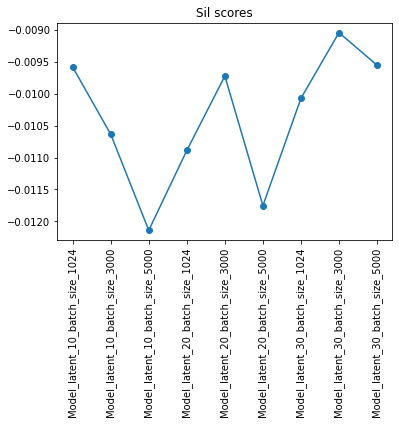

In [7]:
plt.plot(model_scoring_dict['haniffa_ID'].Model,model_scoring_dict['haniffa_ID'].Sil_global_score, **{'marker' : 'o'})
plt.xticks(rotation=90)
plt.title('Sil scores')

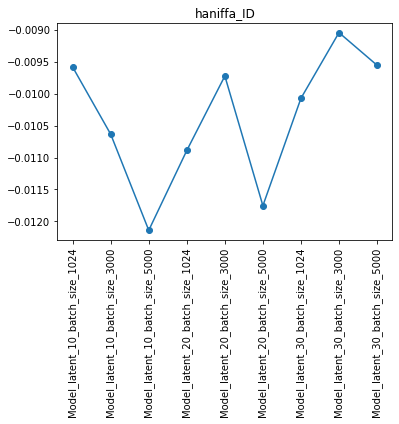

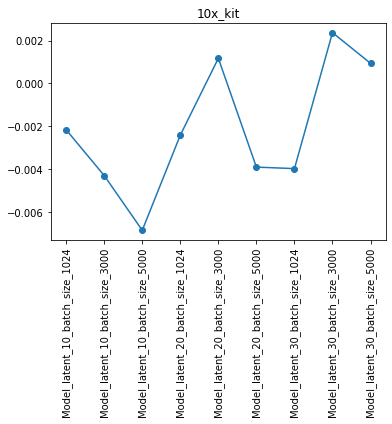

In [8]:
cat = 'Sil_global_score'

for meta in meta_cats:
    plt.plot(model_scoring_dict[meta].Model,model_scoring_dict[meta][cat], **{'marker' : 'o'})
    plt.xticks(rotation=90)
    plt.title(meta)
    plt.show()
    plt.close

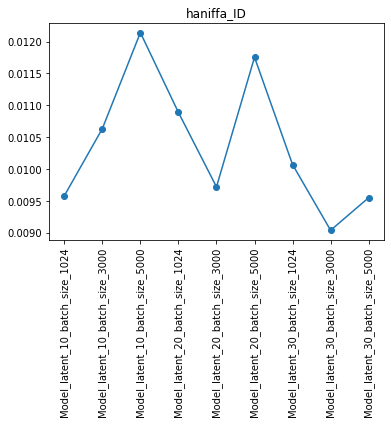

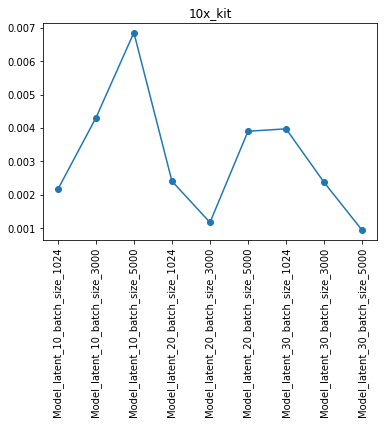

In [9]:
cat = 'Sil_global_score'

for meta in meta_cats:
    plt.plot(model_scoring_dict[meta].Model,abs(model_scoring_dict[meta][cat]), **{'marker' : 'o'})
    plt.xticks(rotation=90)
    plt.title(meta)
    plt.show()
    plt.close

## Determine which model scored the best by each metric and overall which model had the most scores close to 0

- Score close to 0 is optinum for all metrics evaluating
- Shilouette distance scoring is the major metric focussing mostly on 

In [10]:
model_lowest_per_cat = []
for meta in meta_cats:
    print('\033[1m' + f'Scores summary for category: {meta}' + '\033[0m' + '\n')
    for cat in score_cats:
        plt.plot(model_scoring_dict[meta].Model,model_scoring_dict[meta][cat], **{'marker' : 'o'})
        plt.xticks(rotation=90)
        plt.title(meta + ': ' + cat)
        plt.savefig('./Scoring_summary_outs/just_NN_15/' + meta + '_' + cat + '_line_graph.pdf', bbox_inches = "tight")
        plt.close()
        v = model_scoring_dict[meta]['Model'].loc[abs(model_scoring_dict[meta][cat]) == abs(model_scoring_dict[meta][cat]).min()].values[0]
        model_lowest_per_cat.append(v)
        print('The model with the lowest {c} score was: {s}'.format(c=cat, s=v))
    print('\n' * 2)
    
print('\033[1m' + 'Overall:' + '\033[0m' + '\n')
freq = nltk.FreqDist(model_lowest_per_cat)
print(f'The model with the most scores closest to 0 was: {freq.max()}' + '\n')

Scores summary for category: haniffa_ID

The model with the lowest Purity_Score score was: Model_latent_30_batch_size_1024
The model with the lowest Homogeneity_Score score was: Model_latent_20_batch_size_3000
The model with the lowest Completeness_Score score was: Model_latent_20_batch_size_3000
The model with the lowest Normalized_mutual_info_Score score was: Model_latent_20_batch_size_3000
The model with the lowest Sil_global_score score was: Model_latent_30_batch_size_3000



Scores summary for category: 10x_kit

The model with the lowest Purity_Score score was: Model_latent_10_batch_size_1024
The model with the lowest Homogeneity_Score score was: Model_latent_20_batch_size_3000
The model with the lowest Completeness_Score score was: Model_latent_20_batch_size_3000
The model with the lowest Normalized_mutual_info_Score score was: Model_latent_20_batch_size_3000
The model with the lowest Sil_global_score score was: Model_latent_30_batch_size_5000



Overall:

The model with the most

### Sil distance scoring shows all models are very similar to one another and all have very low sil distance scores

### Model latent 20 batch size 3000 does well on sil score for haniffa_ID and 10x_kit and also scores well on other metrics so going a head with this scVI model

#  Evaluate scores for KNN graphs for selected model to move forward with

## Load in summary csv for each neighbourhood and put into dataframe within a dictionary

In [11]:
path = '/home/jupyter/mount/sanger_gdrive/whole_embryo/SCVI_for_n_3_20220606/haniffa_ID_ext_cat_10x_kit_latent_20_batch_size_3000_scvi_outs/plot_outputs/scoring/'

patterns_1 = ('20220725.csv','20220801.csv')
patterns_2 = ('neighbours_15','neighbours_20','neighbours_25','neighbours_30')

files = []

for file in os.listdir(path):
    if(file.endswith(patterns_1)):
        files.append(file)
        print(file)

Scoring_table_for_X_umap_neighbours_15_20220725.csv
Scoring_table_for_X_umap_neighbours_20_20220801.csv
Scoring_table_for_X_umap_neighbours_25_20220801.csv
Scoring_table_for_X_umap_neighbours_30_20220801.csv
sil_sample_scores_for_10x_kit_on_X_umap_neighbours_15_20220725.csv
sil_sample_scores_for_10x_kit_on_X_umap_neighbours_20_20220801.csv
sil_sample_scores_for_10x_kit_on_X_umap_neighbours_25_20220801.csv
sil_sample_scores_for_10x_kit_on_X_umap_neighbours_30_20220801.csv
sil_sample_scores_for_haniffa_ID_on_X_umap_neighbours_15_20220725.csv
sil_sample_scores_for_haniffa_ID_on_X_umap_neighbours_20_20220801.csv
sil_sample_scores_for_haniffa_ID_on_X_umap_neighbours_25_20220801.csv
sil_sample_scores_for_haniffa_ID_on_X_umap_neighbours_30_20220801.csv


In [12]:
scoring_dict = {}

for pattern in patterns_2:
    sub_files = [file for file in files if pattern in file]
    sub_dict = {}
    if pattern == patterns_2[0]:
        date = patterns_1[0].split('.')[0]
    else:
        date = patterns_1[1].split('.')[0]
    sub_dict['model_scores'] = pd.read_csv(path + 'Scoring_table_for_X_umap_' + pattern + '_' + date + '.csv', index_col=0)
    sub_dict['h_sample_scores'] = pd.read_csv(path + 'sil_sample_scores_for_haniffa_ID_on_X_umap_' + pattern + '_' + date + '.csv', index_col=0)
    sub_dict['k_sample_scores'] = pd.read_csv(path + 'sil_sample_scores_for_10x_kit_on_X_umap_' + pattern + '_' + date + '.csv', index_col=0)
    scoring_dict[pattern] = sub_dict
    del sub_dict

In [13]:
scoring_dict.keys()

dict_keys(['neighbours_15', 'neighbours_20', 'neighbours_25', 'neighbours_30'])

In [14]:
scoring_dict['neighbours_15'].keys()

dict_keys(['model_scores', 'h_sample_scores', 'k_sample_scores'])

In [15]:
model_scoring_dict = {}
meta_cats = ['haniffa_ID','10x_kit']

model_scores_df = pd.DataFrame()
model_names = []
for k in scoring_dict.keys():
    model_scores_df = pd.concat([model_scores_df,scoring_dict[k]['model_scores']],ignore_index = True, sort = False).reset_index(drop=True)
    num_list=[i for i in k.split("_") if i.isnumeric()]
    model_names.append('Model_NN_' + num_list[0])
    
model_scores_df.insert(loc=0, column='Model', value = list(np.repeat(list(model_names),2)))
model_scoring_dict['overall'] = model_scores_df
model_scoring_dict[meta_cats[0]] = model_scores_df[model_scores_df.meta_cat.isin([meta_cats[0]])]
model_scoring_dict[meta_cats[1]] = model_scores_df[model_scores_df.meta_cat.isin([meta_cats[1]])]

In [16]:
model_scoring_dict['haniffa_ID']

,Model,Basis,meta_cat,Purity_Score,Homogeneity_Score,Completeness_Score,Normalized_mutual_info_Score,Sil_global_score
0,Model_NN_15,X_umap_neighbours_15,haniffa_ID,0.443147,0.032327,0.010750,0.016135,-0.009722
2,Model_NN_20,X_umap_neighbours_20,haniffa_ID,0.447512,0.033055,0.011363,0.016912,-0.010628
4,Model_NN_25,X_umap_neighbours_25,haniffa_ID,0.442802,0.031854,0.011181,0.016552,-0.011135
6,Model_NN_30,X_umap_neighbours_30,haniffa_ID,0.440065,0.031027,0.010817,0.016042,-0.010112


In [17]:
model_scoring_dict['10x_kit']

,Model,Basis,meta_cat,Purity_Score,Homogeneity_Score,Completeness_Score,Normalized_mutual_info_Score,Sil_global_score
1,Model_NN_15,X_umap_neighbours_15,10x_kit,0.738521,0.026322,0.004647,0.007900,0.001175
3,Model_NN_20,X_umap_neighbours_20,10x_kit,0.738522,0.025837,0.004715,0.007975,-0.000445
5,Model_NN_25,X_umap_neighbours_25,10x_kit,0.738519,0.024007,0.004474,0.007542,-0.001550
7,Model_NN_30,X_umap_neighbours_30,10x_kit,0.738521,0.026503,0.004906,0.008279,0.000059


## Visulaise silhouette distance scores

In [18]:
score_cats = ['Purity_Score','Homogeneity_Score','Completeness_Score','Normalized_mutual_info_Score','Sil_global_score']

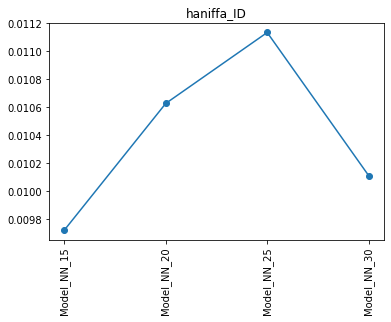

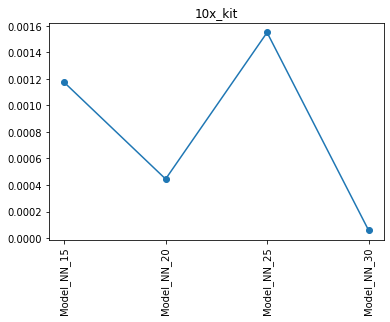

In [19]:
cat = 'Sil_global_score'

for meta in meta_cats:
    plt.plot(model_scoring_dict[meta].Model,abs(model_scoring_dict[meta][cat]), **{'marker' : 'o'})
    plt.xticks(rotation=90)
    plt.title(meta)
    plt.show()
    plt.close

## Determine which KNN graph scored the best by each metric and overall which model had the most scores close to 0

- Score close to 0 is optinum for all metrics evaluating
- Shilouette distance scoring is the major metric focussing mostly on 

In [20]:
model_lowest_per_cat = []
for meta in meta_cats:
    print('\033[1m' + f'Scores summary for category: {meta}' + '\033[0m' + '\n')
    for cat in score_cats:
        plt.plot(model_scoring_dict[meta].Model,model_scoring_dict[meta][cat], **{'marker' : 'o'})
        plt.xticks(rotation=90)
        plt.title(meta + ': ' + cat)
        plt.savefig('./Scoring_summary_outs/latent_10_batch_1024_NNs/' + meta + '_' + cat + '_line_graph.pdf', bbox_inches = "tight")
        plt.close()
        v = model_scoring_dict[meta]['Model'].loc[abs(model_scoring_dict[meta][cat]) == abs(model_scoring_dict[meta][cat]).min()].values[0]
        model_lowest_per_cat.append(v)
        print('The KNN graph with the lowest {c} score was: {s}'.format(c=cat, s=v))
    print('\n' * 2)
    
print('\033[1m' + 'Overall:' + '\033[0m' + '\n')
freq = nltk.FreqDist(model_lowest_per_cat)
print(f'The KNN graph with the most scores closest to 0 was: {freq.max()}' + '\n')

Scores summary for category: haniffa_ID

The KNN graph with the lowest Purity_Score score was: Model_NN_30
The KNN graph with the lowest Homogeneity_Score score was: Model_NN_30
The KNN graph with the lowest Completeness_Score score was: Model_NN_15
The KNN graph with the lowest Normalized_mutual_info_Score score was: Model_NN_30
The KNN graph with the lowest Sil_global_score score was: Model_NN_15



Scores summary for category: 10x_kit

The KNN graph with the lowest Purity_Score score was: Model_NN_25
The KNN graph with the lowest Homogeneity_Score score was: Model_NN_25
The KNN graph with the lowest Completeness_Score score was: Model_NN_25
The KNN graph with the lowest Normalized_mutual_info_Score score was: Model_NN_25
The KNN graph with the lowest Sil_global_score score was: Model_NN_30



Overall:

The KNN graph with the most scores closest to 0 was: Model_NN_30



## All KNN graph seem to have performed well due to very low scoring

## NN 30 seems to have done well overall and scores 2nd best for sil on haniffa_ID and best (almost perfect) on chemistry. This is favoured as chemistry qualatatively had a greater impact of technical batch over donor

***
### Dependencies
Here are some information about resources and import package versions used within this script

In [21]:
%load_ext watermark
%watermark -v -m -p numpy,pandas,scanpy,anndata,scvi,sklearn

Global seed set to 0


Python implementation: CPython
Python version       : 3.9.4
IPython version      : 7.31.1

numpy  : 1.20.3
pandas : 1.4.0
scanpy : 1.7.2
anndata: 0.7.6
scvi   : 0.6.8
sklearn: 1.0.2

Compiler    : GCC 9.3.0
OS          : Linux
Release     : 4.19.0-23-cloud-amd64
Machine     : x86_64
Processor   : 
CPU cores   : 32
Architecture: 64bit

